In [1]:
import pandas as pd
import numpy as np
import matplotlib. pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Object means here alphanumeric i.e---> customerID
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Replacing blanks with 0 as tenure is  0 and no total_charges are recorded

In [5]:
#df["TotalCharges"]=df["TotalCharges"].replace("","0")
#df["TotalCharges"]=df["TotalCharges"].astype("float")
#df["TotalCharges"] = df["TotalCharges"].str.strip()
df["TotalCharges"] = df["TotalCharges"].replace("", "0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [6]:
# isnull is a function used to check were the value is null or not 
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df["customerID"].duplicated().sum()

np.int64(0)

In [9]:
#converted 0 and 1 values of senior citizen to yes/no to make it easier to understand
def conr(value):
    if value==1:
        return "Yes"
    else:
        return "No"
df[ 'SeniorCitizen' ]=df[ 'SeniorCitizen' ].apply(conr)


In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<function matplotlib.pyplot.show(close=None, block=None)>

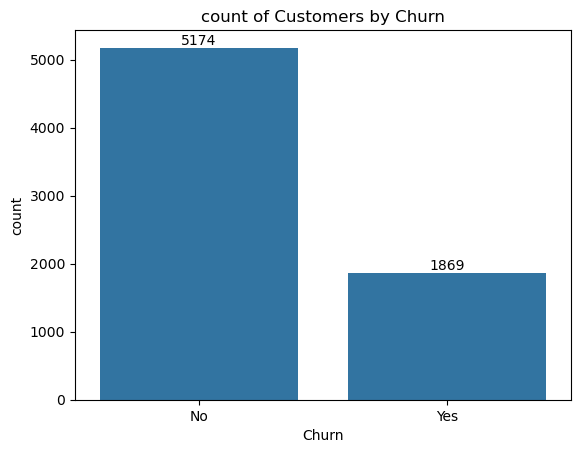

In [11]:
a = sns.countplot(x='Churn',data=df)
a.bar_label(a.containers[0])
plt.title("count of Customers by Churn")
plt.show

In [12]:
gb= df.groupby("Churn").agg({'Churn':"count"})
gb

,Churn
Churn,
No,5174
Yes,1869


<function matplotlib.pyplot.show(close=None, block=None)>

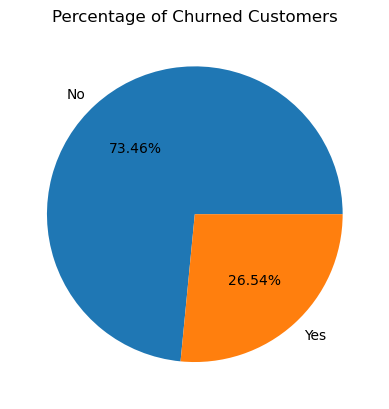

In [13]:
gb= df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels=gb.index, autopct="%1.2f%%" )
plt.title("Percentage of Churned Customers")
plt.show

### let's explore the reason why customers have churned out.

<function matplotlib.pyplot.show(close=None, block=None)>

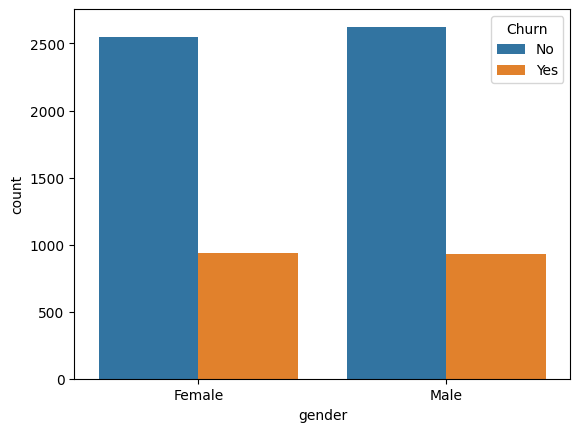

In [ ]:
sns.countplot(x="gender", data=df, hue="Churn")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

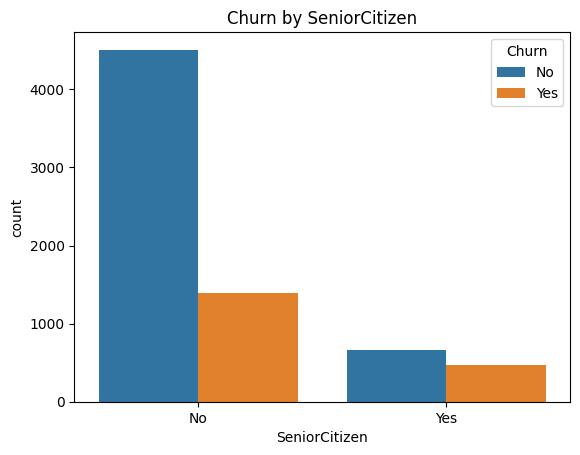

In [ ]:
sns.countplot(x="SeniorCitizen", data=df, hue="Churn")
plt.title("Churn by SeniorCitizen")
plt.show

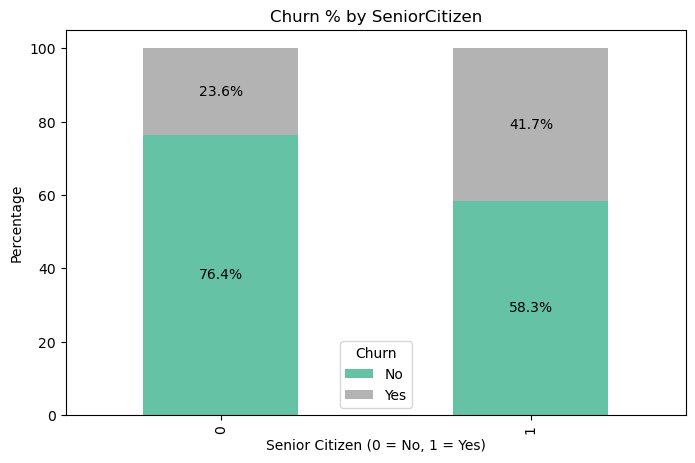

In [5]:
# Create a cross-tab (counts)
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Convert to percentage
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked bar
ax = ct_pct.plot(kind='bar', stacked=True, figsize=(8,5), colormap="Set2")

# Add labels as %
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center')

plt.title("Churn % by SeniorCitizen")
plt.ylabel("Percentage")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.legend(title="Churn")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

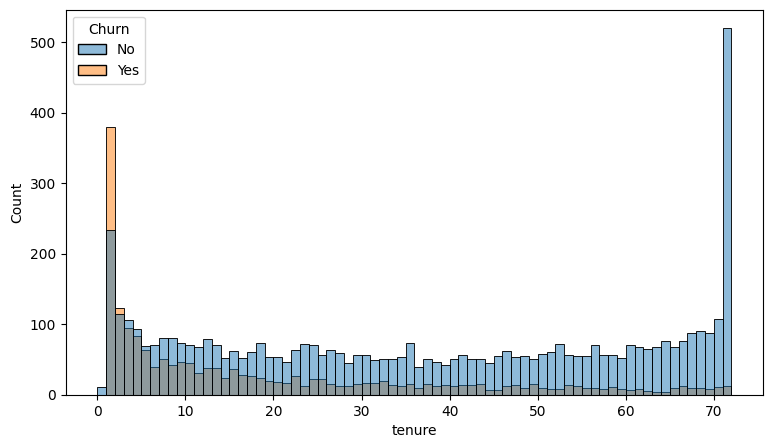

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(x="tenure", data=df, bins=72, hue="Churn")
plt.show

comparative a greater pecentage of people in senior citizen category have churned

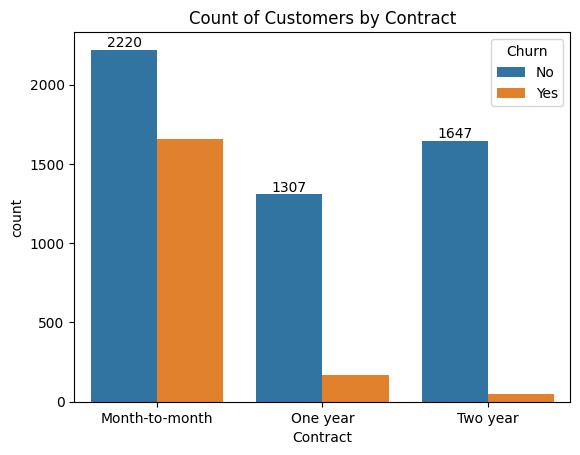

In [37]:
a = sns.countplot(x = "Contract", data = df, hue = "Churn")
a.bar_label(a.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract. 


In [38]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

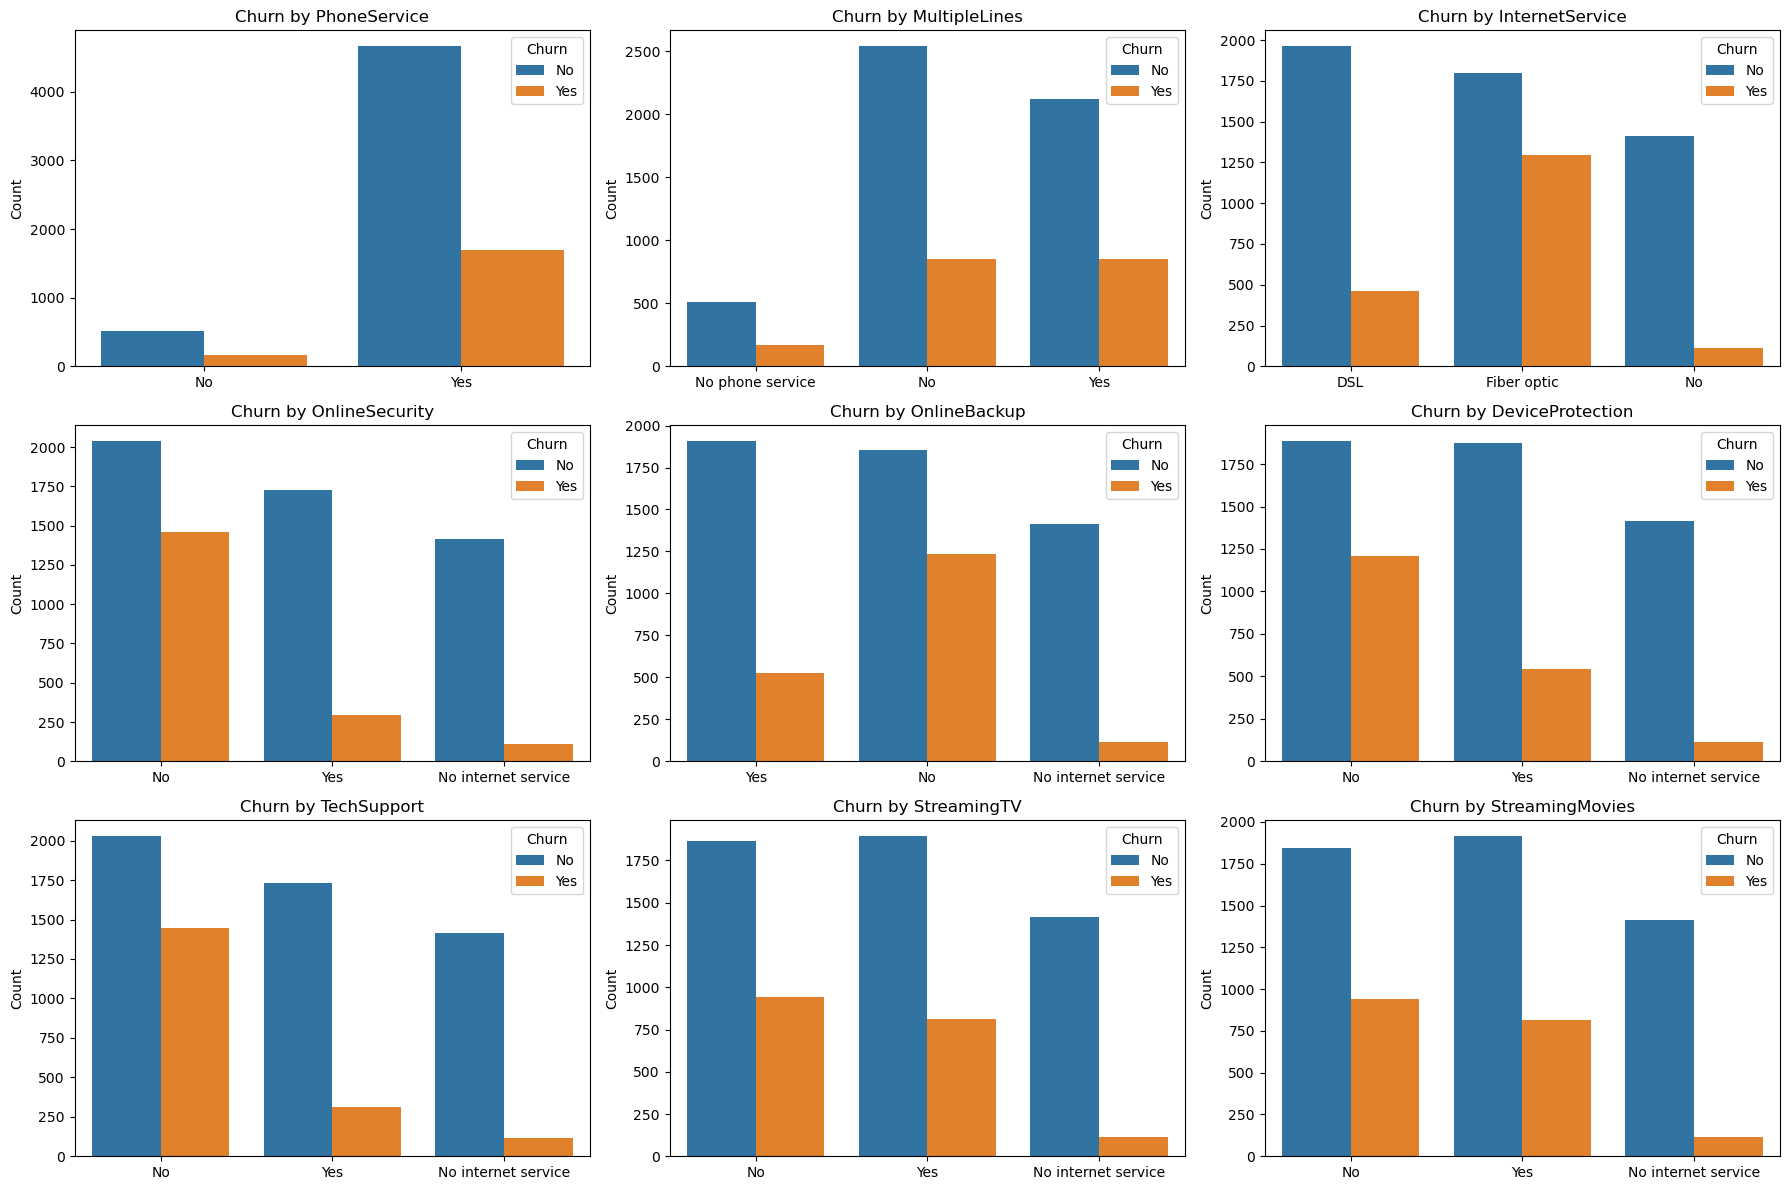

In [6]:
cols = [
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

# Subplots grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=col, data=df,hue="Churn", ax=axes[i])
    axes[i].set_title(f"Churn by {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Churn")

# Remove empty subplot if columns < grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable.

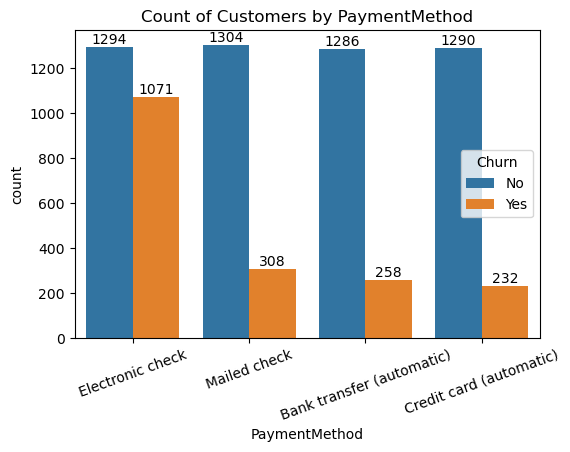

In [18]:
plt.figure(figsize=(6,4))
a = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.title("Count of Customers by PaymentMethod")
plt.xticks(rotation = 20)
plt.show()

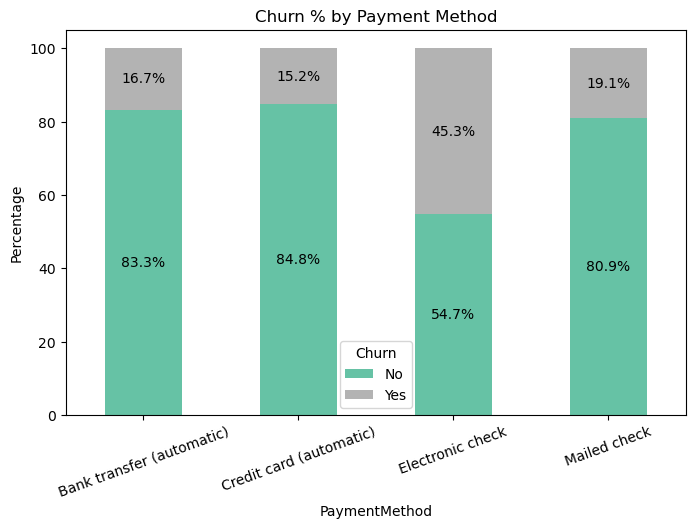

In [15]:
ct = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
ax = ct.plot(kind='bar', stacked=True, figsize=(8,5), colormap="Set2")
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center')
plt.title("Churn % by Payment Method")
plt.xticks(rotation = 20)
plt.ylabel("Percentage")
plt.show()


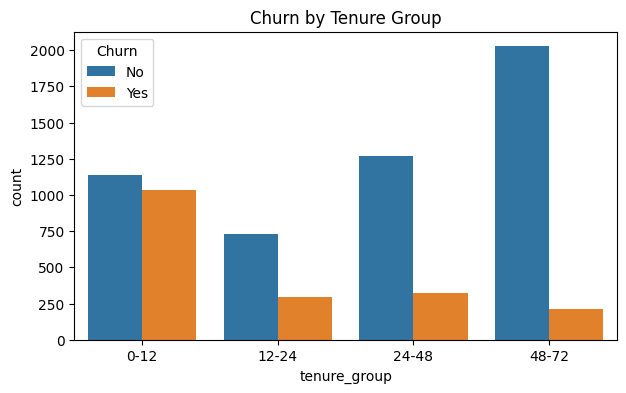

In [11]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], 
                            labels=['0-12','12-24','24-48','48-72'])
plt.figure(figsize=(7,4))
sns.countplot(x="tenure_group", hue="Churn", data=df)
plt.title("Churn by Tenure Group")
plt.show()


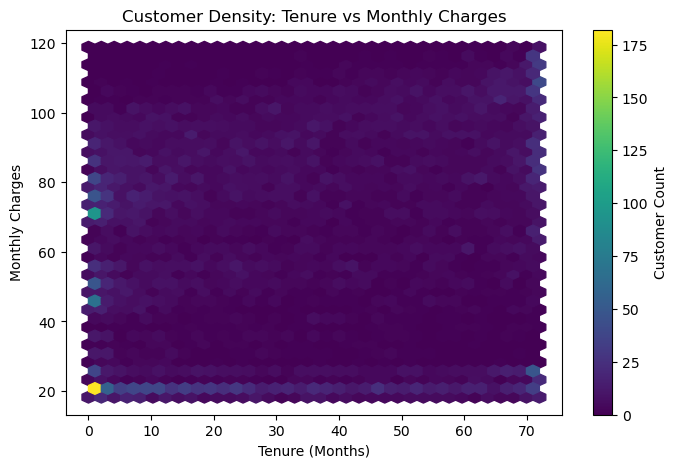

In [11]:

df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")

df = df.dropna(subset=["tenure", "MonthlyCharges"])

plt.figure(figsize=(8, 5))

plt.hexbin(
    df["tenure"],
    df["MonthlyCharges"],
    gridsize=35
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.title("Customer Density: Tenure vs Monthly Charges")

plt.colorbar(label="Customer Count")

plt.show()